In [1]:
# ============================================================
# WEEK 1 TASK
# Data Acquisition, Cleaning, and Exploratory Data Analysis
# Dataset: Netflix Movies and TV Shows
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# 2. DATA ACQUISITION
# ============================================================

# After uploading netflix_titles.csv to Colab session storage:
file_path = "netflix_titles.csv"

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'netflix_titles.csv' not found in session storage.")
    print("Please upload the file using the folder icon on the left sidebar.")

Dataset loaded successfully.


In [7]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape:
(6234, 12)

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [8]:
# Dataset information

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [9]:
# Column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [10]:
# Statistical summary

print("Statistical Summary:")
display(df.describe(include="all").T)

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,6234.0,NaN,NaN,NaN,76703679.319859,10942964.649885,247747.0,80035801.75,80163367.0,80244888.75,81235729.0
type,6234,2,Movie,4265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,6234,6172,The Silence,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,4265,3301,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,5664,5469,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5758,554,United States,2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,6223,1524,"January 1, 2020",122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,6234.0,NaN,NaN,NaN,2013.35932,8.81162,1925.0,2013.0,2016.0,2018.0,2020.0
rating,6224,14,TV-MA,2027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,6234,201,1 Season,1321,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# ============================================================
# 4. MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Percentage
director,1969,31.584857
cast,570,9.143407
country,476,7.635547
date_added,11,0.176452
rating,10,0.160411
title,0,0.000000
show_id,0,0.000000
type,0,0.000000
release_year,0,0.000000
duration,0,0.000000


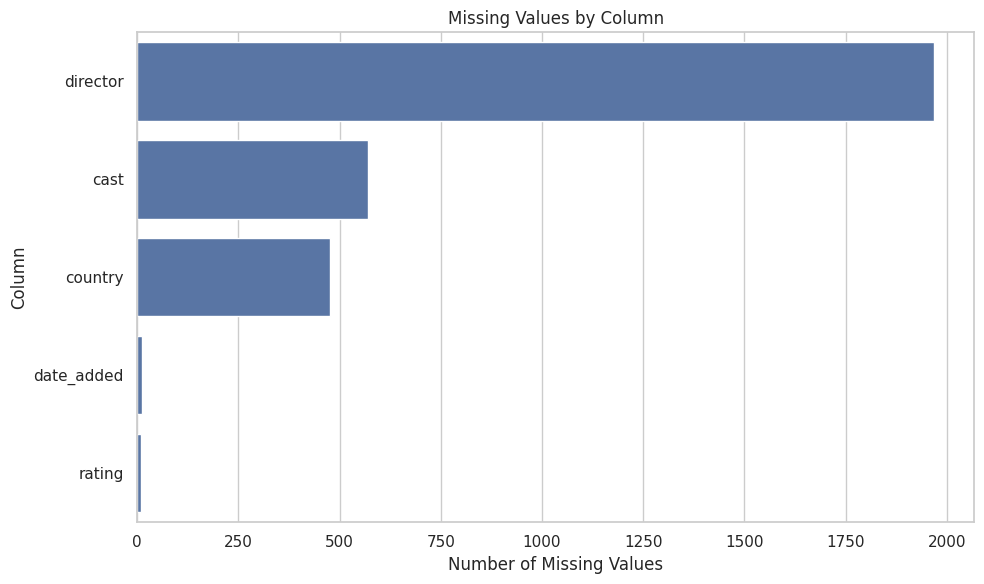

In [12]:
# ============================================================
# VISUALIZATION 1
# Missing Values by Column
# ============================================================

missing_plot = missing_summary[
    missing_summary["Missing Values"] > 0
]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_plot["Missing Values"],
    y=missing_plot.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 5. DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:
# Remove duplicate records

if duplicate_count > 0:
    df = df.drop_duplicates().copy()

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (6234, 12)


In [15]:
# ============================================================
# 6. UNIQUE VALUE ANALYSIS
# ============================================================

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

show_id: 6234 unique values
type: 2 unique values
title: 6172 unique values
director: 3301 unique values
cast: 5469 unique values
country: 554 unique values
date_added: 1524 unique values
release_year: 72 unique values
rating: 14 unique values
duration: 201 unique values
listed_in: 461 unique values
description: 6226 unique values


In [16]:
# ============================================================
# 7. DATA TYPES
# ============================================================

print("Data types before cleaning:")
print(df.dtypes)

Data types before cleaning:
show_id          int64
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [17]:
# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

# Make an explicit copy before modifying the dataframe
df = df.copy()

# Categorical columns where missing information should be retained
categorical_columns = [
    "director",
    "cast",
    "country"
]

for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")

In [18]:
# Fill missing rating values with the mode

if "rating" in df.columns:
    rating_mode = df["rating"].mode()

    if not rating_mode.empty:
        df["rating"] = df["rating"].fillna(rating_mode.iloc[0])

In [19]:
# Convert date_added to datetime

if "date_added" in df.columns:

    df["date_added"] = pd.to_datetime(
        df["date_added"],
        errors="coerce"
    )

In [20]:
# ============================================================
# 9. REMOVE UNNECESSARY WHITESPACE
# ============================================================

object_columns = df.select_dtypes(
    include="object"
).columns

for column in object_columns:

    df[column] = df[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Whitespace cleaning completed.")

Whitespace cleaning completed.


In [21]:
# ============================================================
# 10. CREATE DATE FEATURES
# ============================================================

df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["month_name"] = df["date_added"].dt.month_name()

print("Date features created successfully.")

Date features created successfully.


In [22]:
# ============================================================
# 11. FINAL DATA QUALITY CHECK
# ============================================================

final_missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().sum() / len(df) * 100
})

display(
    final_missing.sort_values(
        by="Missing Values",
        ascending=False
    )
)

,Missing Values,Percentage
date_added,651,10.442733
month_name,651,10.442733
month_added,651,10.442733
year_added,651,10.442733
title,0,0.000000
type,0,0.000000
show_id,0,0.000000
country,0,0.000000
cast,0,0.000000
director,0,0.000000


In [23]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [24]:
# ============================================================
# 13. FINAL DATASET INFORMATION
# ============================================================

print("Final Dataset Shape:", df.shape)

print("\nFinal Data Types:")
print(df.dtypes)

print("\nFinal Dataset Information:")
df.info()

Final Dataset Shape: (6234, 15)

Final Data Types:
show_id                  int64
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added             float64
month_added            float64
month_name              object
dtype: object

Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       6234 non-null   int64         
 1   type          6234 non-null   object        
 2   title         6234 non-null   object        
 3   director      6234 non-null   object        
 4   cast          6234 non-null   

In [25]:
# ============================================================
# 14. SAVE CLEANED DATASET
# ============================================================

cleaned_file = "netflix_cleaned.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print(f"Cleaned dataset saved as: {cleaned_file}")

Cleaned dataset saved as: netflix_cleaned.csv


In [26]:
# ============================================================
# EDA 1: MOVIES VS TV SHOWS
# ============================================================

content_type = df["type"].value_counts()

print("Content Type Distribution:")
display(content_type)

Content Type Distribution:


,count
type,
Movie,4265
TV Show,1969


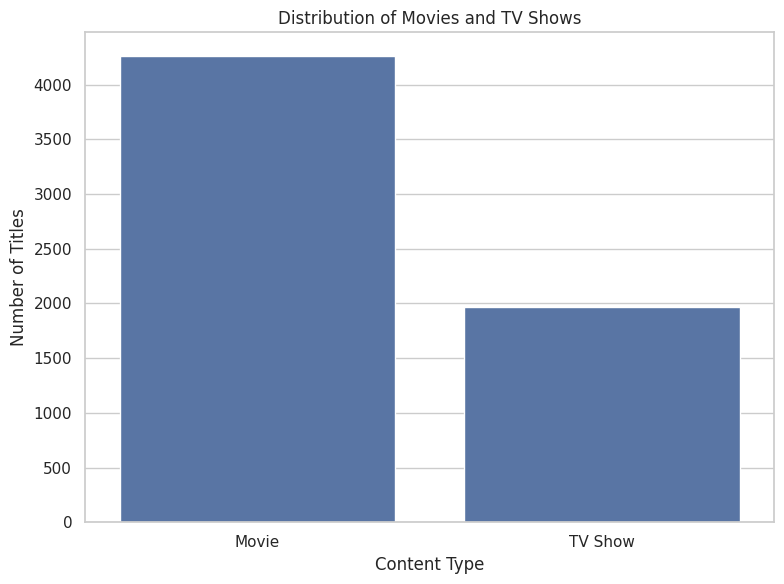

In [27]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=content_type.index,
    y=content_type.values
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [28]:
# Calculate percentages

content_percentage = (
    df["type"].value_counts(normalize=True) * 100
)

display(
    content_percentage.round(2)
)

,proportion
type,
Movie,68.42
TV Show,31.58


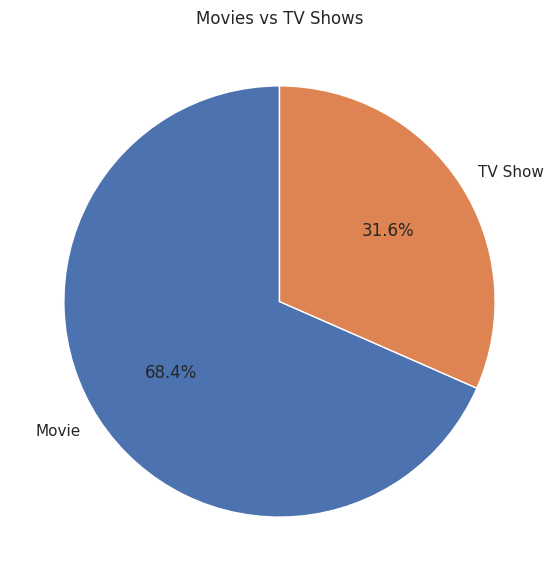

In [29]:
plt.figure(figsize=(7, 7))

plt.pie(
    content_type.values,
    labels=content_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")

plt.show()

In [30]:
# ============================================================
# EDA 2: CONTENT ADDED OVER TIME
# ============================================================

year_added_counts = (
    df["year_added"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

display(year_added_counts)

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,7
2013,9
2014,19
2015,74
2016,412


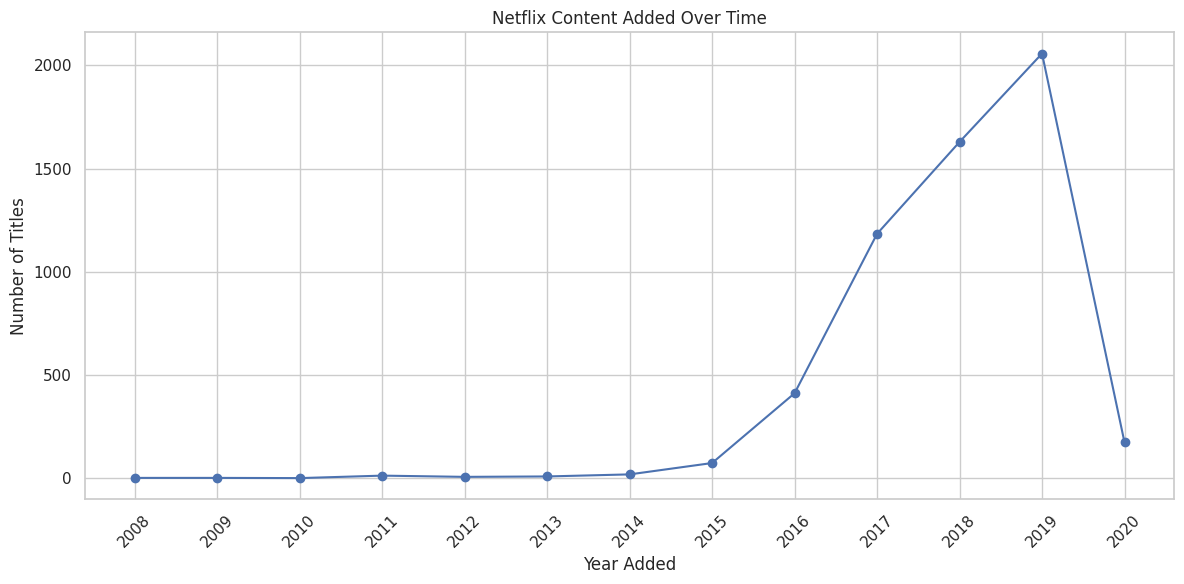

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(
    year_added_counts.index,
    year_added_counts.values,
    marker="o"
)

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.xticks(
    year_added_counts.index,
    rotation=45
)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# EDA 3: COUNTRY ANALYSIS
# ============================================================

country_data = (
    df["country"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
    .str.strip()
)

country_counts = country_data.value_counts()

print("Top 20 countries:")
display(country_counts.head(20))

Top 20 countries:


,count
country,
United States,2609
India,838
United Kingdom,601
Unknown,476
Canada,318
France,271
Japan,231
Spain,178
South Korea,162


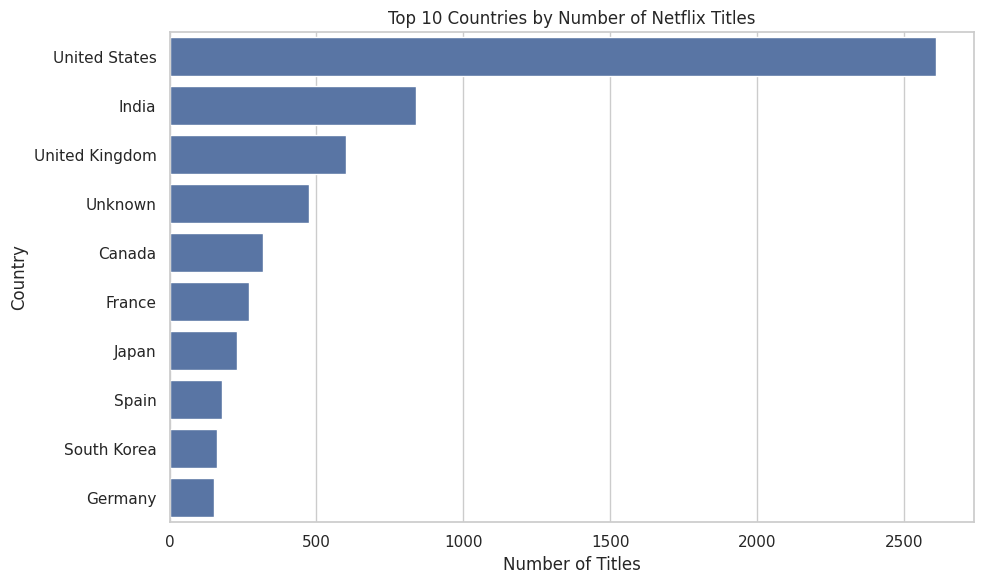

In [33]:
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# EDA 4: RELEASE YEAR
# ============================================================

print("Oldest release year:", df["release_year"].min())
print("Newest release year:", df["release_year"].max())
print(
    "Average release year:",
    round(df["release_year"].mean(), 2)
)

Oldest release year: 1925
Newest release year: 2020
Average release year: 2013.36


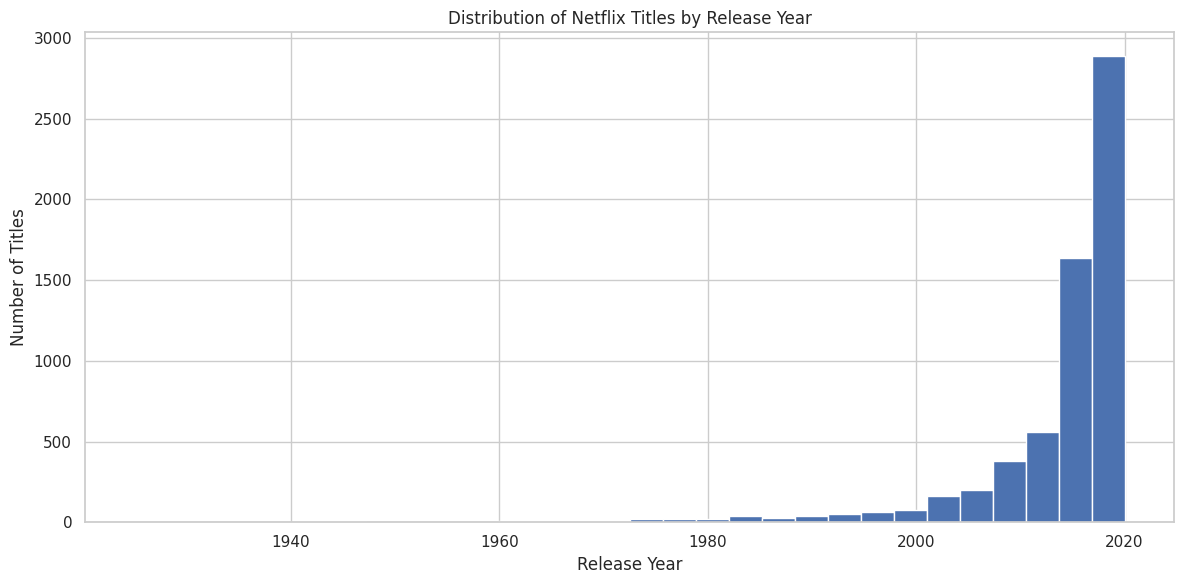

In [35]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["release_year"],
    bins=30
)

plt.title("Distribution of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# EDA 5: CONTENT RATINGS
# ============================================================

rating_counts = df["rating"].value_counts()

print("Content Ratings:")
display(rating_counts)

Content Ratings:


,count
rating,
TV-MA,2037
TV-14,1698
TV-PG,701
R,508
PG-13,286
NR,218
PG,184
TV-Y7,169
TV-G,149


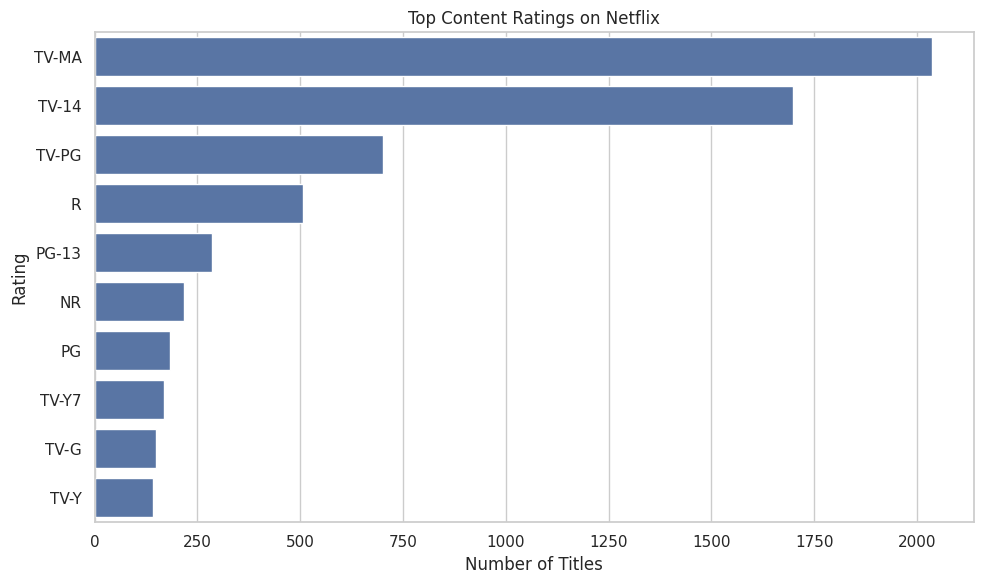

In [37]:
top_ratings = rating_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index
)

plt.title("Top Content Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# EDA 6: MOVIE DURATION
# ============================================================

movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

print("Movie duration statistics:")

display(
    movies["duration_minutes"].describe()
)

Movie duration statistics:


,duration_minutes
count,4265.000000
mean,99.100821
std,28.074857
min,3.000000
25%,86.000000
50%,98.000000
75%,115.000000
max,312.000000


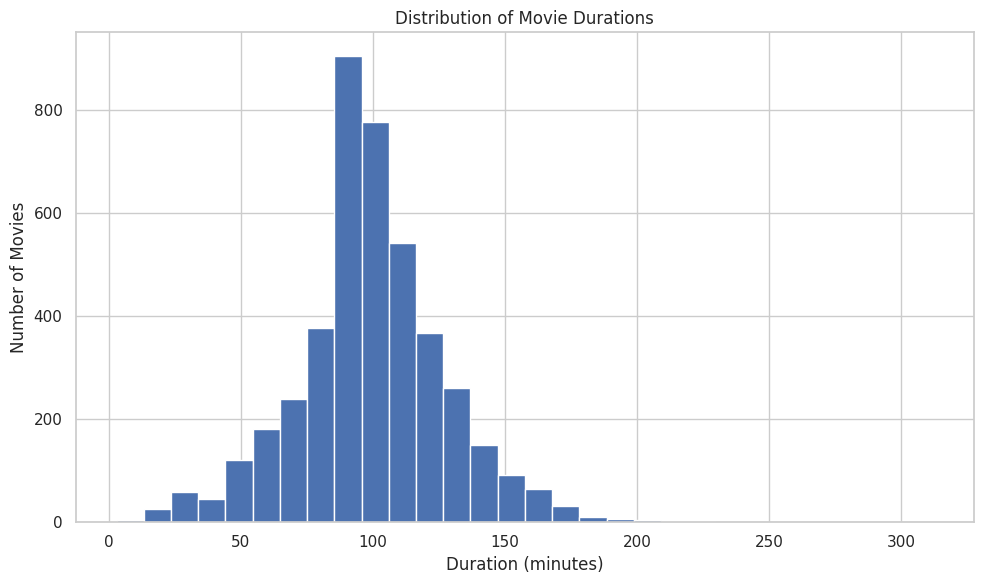

In [39]:
plt.figure(figsize=(10, 6))

plt.hist(
    movies["duration_minutes"].dropna(),
    bins=30
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

In [40]:

# ============================================================
# EDA 7: TV SHOW SEASONS
# ============================================================

tv_shows = df[df["type"] == "TV Show"].copy()

tv_shows["seasons"] = (
    tv_shows["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

print("TV Show Season Statistics:")

display(
    tv_shows["seasons"].describe()
)

TV Show Season Statistics:


,seasons
count,1969.000000
mean,1.779584
std,1.624936
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,15.000000


In [41]:
# ============================================================
# EDA 8: GENRE ANALYSIS
# ============================================================

genre_data = (
    df["listed_in"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
    .str.strip()
)

genre_counts = genre_data.value_counts()

print("Top 20 Genres:")
display(genre_counts.head(20))

Top 20 Genres:


,count
listed_in,
International Movies,1927
Dramas,1623
Comedies,1113
International TV Shows,1001
Documentaries,668
TV Dramas,599
Action & Adventure,597
Independent Movies,552
TV Comedies,436


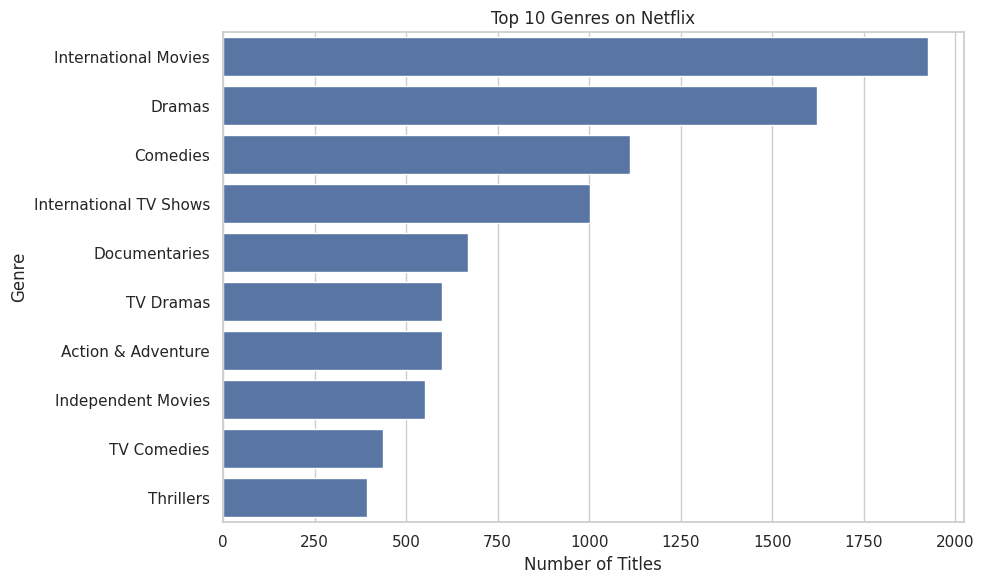

In [42]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# EDA 9: CONTENT TYPE OVER RELEASE YEAR
# ============================================================

type_year = (
    df.groupby(
        ["release_year", "type"]
    )
    .size()
    .unstack(fill_value=0)
)

display(type_year.tail(20))

type,Movie,TV Show
release_year,,
2001,30,4
2002,35,3
2003,35,8
2004,40,9
2005,51,12
2006,59,9
2007,60,11
2008,87,20
2009,87,34


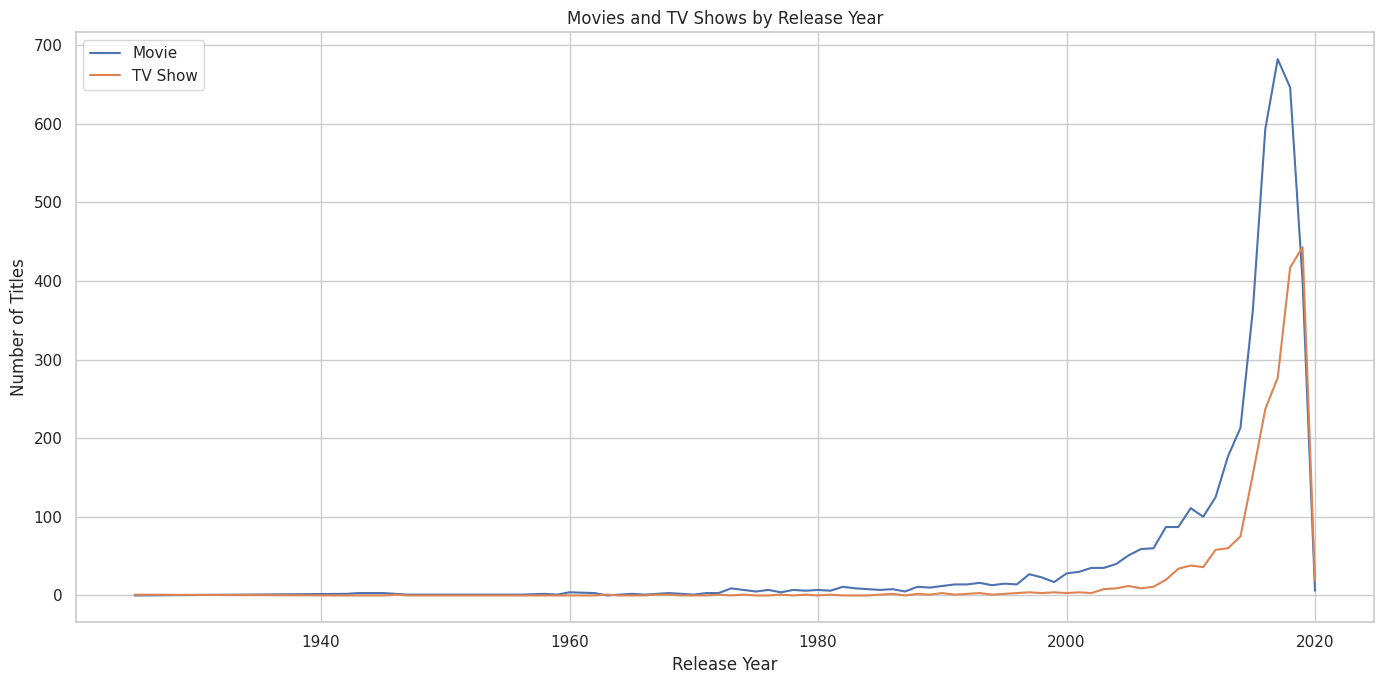

In [44]:
plt.figure(figsize=(14, 7))

if "Movie" in type_year.columns:
    plt.plot(
        type_year.index,
        type_year["Movie"],
        label="Movie"
    )

if "TV Show" in type_year.columns:
    plt.plot(
        type_year.index,
        type_year["TV Show"],
        label="TV Show"
    )

plt.title("Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# EDA 10: CORRELATION ANALYSIS
# ============================================================

correlation_df = df[
    [
        "release_year",
        "year_added"
    ]
].copy()

correlation_df = correlation_df.dropna()

correlation_matrix = correlation_df.corr()

display(correlation_matrix)

,release_year,year_added
release_year,1.000000,0.023812
year_added,0.023812,1.000000


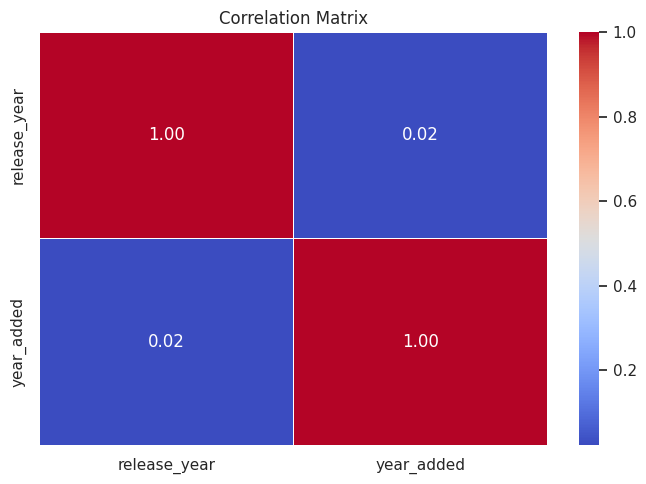

In [46]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# 26. SUMMARY STATISTICS
# ============================================================

print("Numerical Summary:")

display(
    df[
        ["release_year", "year_added"]
    ].describe()
)

Numerical Summary:


,release_year,year_added
count,6234.00000,5583.000000
mean,2013.35932,2017.977611
std,8.81162,1.204033
min,1925.00000,2008.000000
25%,2013.00000,2017.000000
50%,2016.00000,2018.000000
75%,2018.00000,2019.000000
max,2020.00000,2020.000000


In [48]:
# ============================================================
# 27. AUTOMATIC SUMMARY
# ============================================================

total_titles = len(df)

movies_count = (
    (df["type"] == "Movie").sum()
)

tv_count = (
    (df["type"] == "TV Show").sum()
)

movie_percentage = movies_count / total_titles * 100
tv_percentage = tv_count / total_titles * 100

print("========== DATASET SUMMARY ==========")

print("Total titles:", total_titles)

print(
    f"Movies: {movies_count} "
    f"({movie_percentage:.2f}%)"
)

print(
    f"TV Shows: {tv_count} "
    f"({tv_percentage:.2f}%)"
)

print(
    "Oldest release year:",
    df["release_year"].min()
)

print(
    "Newest release year:",
    df["release_year"].max()
)

print(
    "Most common rating:",
    df["rating"].mode()[0]
)

print(
    "Top country:",
    country_counts.index[0]
)

print(
    "Top genre:",
    genre_counts.index[0]
)

========== DATASET SUMMARY ==========
Total titles: 6234
Movies: 4265 (68.42%)
TV Shows: 1969 (31.58%)
Oldest release year: 1925
Newest release year: 2020
Most common rating: TV-MA
Top country: United States
Top genre: International Movies


In [49]:
# ============================================================
# DATA QUALITY REPORT
# ============================================================

print("Final Data Quality Report")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Total missing values:",
    df.isnull().sum().sum()
)

print("\nMissing values by column:")

display(
    df.isnull().sum()
    .sort_values(ascending=False)
)

Final Data Quality Report
Rows: 6234
Columns: 15
Duplicate rows: 0
Total missing values: 2604

Missing values by column:


,0
date_added,651
month_name,651
month_added,651
year_added,651
title,0
type,0
show_id,0
country,0
cast,0
director,0


In [50]:
# ============================================================
# 29. EXPORT IMPORTANT RESULTS
# ============================================================

country_counts.head(20).to_csv(
    "top_countries.csv"
)

genre_counts.head(20).to_csv(
    "top_genres.csv"
)

rating_counts.to_csv(
    "rating_distribution.csv"
)

content_type.to_csv(
    "content_type_distribution.csv"
)

year_added_counts.to_csv(
    "content_added_by_year.csv"
)

print("EDA result files exported successfully.")

EDA result files exported successfully.


In [51]:
# ============================================================
# FINAL OUTPUT
# ============================================================

print("=" * 60)
print("WEEK 1 DATA PREPARATION COMPLETED")
print("=" * 60)

print("\nFinal Dataset Shape:", df.shape)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 cleaned records:")
display(df.head())

WEEK 1 DATA PREPARATION COMPLETED

Final Dataset Shape: (6234, 15)
Duplicate Rows: 0
Total Missing Values: 2604

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'month_name']

First 5 cleaned records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019.0,9.0,September
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016.0,9.0,September
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018.0,9.0,September
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018.0,9.0,September
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017.0,9.0,September
